In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Sales.csv")
df.head(5)

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,...,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Max,Min,If,if,ifs
0,11/26/2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,...,45,120,590,360,950,87.0,17.0,NaN,NaN,NaN
1,2/19/2014,19,February,2014,87,Seniors (64+),F,Germany,Saarland,Accessories,...,45,120,107,90,197,15096.0,-30.0,NaN,NaN,NaN
2,12/17/2015,17,December,2015,27,Young Adults (25-34),F,France,Yveline,Clothing,...,42,54,-30,1302,1272,NaN,NaN,NaN,NaN,NaN
3,12/17/2013,17,December,2013,27,Young Adults (25-34),F,France,Yveline,Clothing,...,42,54,-29,1260,1231,NaN,NaN,NaN,NaN,NaN
4,10/9/2013,9,October,2013,31,Young Adults (25-34),M,France,Yveline,Clothing,...,42,54,-25,1092,1067,NaN,NaN,NaN,NaN,NaN


In [3]:
print(df.shape)
df.columns.tolist()

(113036, 23)


['Date',
 'Day',
 'Month',
 'Year',
 'Customer_Age',
 'Age_Group',
 'Customer_Gender',
 'Country',
 'State',
 'Product_Category',
 'Sub_Category',
 'Product',
 'Order_Quantity',
 'Unit_Cost',
 'Unit_Price',
 'Profit',
 'Cost',
 'Revenue',
 'Max',
 'Min',
 'If',
 'if',
 'ifs']

In [4]:
print("check Missing Value")
print(df.isnull().sum())

check Missing Value
Date                     0
Day                      0
Month                    0
Year                     0
Customer_Age             0
Age_Group                0
Customer_Gender          0
Country                  0
State                    0
Product_Category         0
Sub_Category             0
Product                  0
Order_Quantity           0
Unit_Cost                0
Unit_Price               0
Profit                   0
Cost                     0
Revenue                  0
Max                 113034
Min                 113034
If                  113036
if                  113036
ifs                 113036
dtype: int64


In [5]:
df.drop(columns=['Max','Min','If',"if","ifs"],inplace=True)


In [6]:
print("check Missing Value")
print(df.isnull().sum())

check Missing Value
Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64


In [7]:
print("check duplicate")
print(df.duplicated().sum())

check duplicate
1000


In [8]:
df = df.drop_duplicates()
print("check duplicate")
print(df.duplicated().sum())

check duplicate
0


In [10]:
revenue_by_category = df.groupby("Product_Category")["Revenue"].sum()
#print(revenue_by_category)

revenue_by_category = revenue_by_category.sort_values(ascending=False)
print(revenue_by_category)

Product_Category
Bikes          61434484
Accessories    15022766
Clothing        8369522
Name: Revenue, dtype: int64


In [11]:
revenue_by_subcate = df.groupby(["Product_Category","Sub_Category"])["Revenue"].sum()
print(revenue_by_subcate)

Product_Category  Sub_Category     
Accessories       Bike Racks             517800
                  Bike Stands            342830
                  Bottles and Cages     1390570
                  Cleaners               198821
                  Fenders               1245733
                  Helmets               5738482
                  Hydration Packs        990406
                  Tires and Tubes       4598124
Bikes             Mountain Bikes       21020794
                  Road Bikes           33150708
                  Touring Bikes         7262982
Clothing          Caps                   548777
                  Gloves                 871419
                  Jerseys               4112382
                  Shorts                1740710
                  Socks                  147171
                  Vests                  949063
Name: Revenue, dtype: int64


In [12]:
sort_df = df.sort_values(by=["Product_Category","Revenue"],ascending=[True,False])
print(sort_df.head(10))

             Date  Day      Month  Year  Customer_Age             Age_Group  \
111760   1/7/2016    7    January  2016            31  Young Adults (25-34)   
111735  1/17/2014   17    January  2014            53        Adults (35-64)   
111736  2/12/2014   12   February  2014            46        Adults (35-64)   
111698   1/7/2014    7    January  2014            31  Young Adults (25-34)   
111697  1/17/2016   17    January  2016            53        Adults (35-64)   
111342  9/23/2015   23  September  2015            41        Adults (35-64)   
111347  1/26/2016   26    January  2016            35        Adults (35-64)   
111382  6/11/2016   11       June  2016            45        Adults (35-64)   
111345  2/12/2016   12   February  2016            46        Adults (35-64)   
111346  5/11/2016   11        May  2016            32  Young Adults (25-34)   

       Customer_Gender         Country             State Product_Category  \
111760               M          Canada  British Colum

In [13]:
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()
print(corr_matrix)

                     Day      Year  Customer_Age  Order_Quantity  Unit_Cost  \
Day             1.000000 -0.007435     -0.015186       -0.002845   0.003520   
Year           -0.007435  1.000000      0.040879        0.124091  -0.217431   
Customer_Age   -0.015186  0.040879      1.000000        0.027376  -0.021401   
Order_Quantity -0.002845  0.124091      0.027376        1.000000  -0.516289   
Unit_Cost       0.003520 -0.217431     -0.021401       -0.516289   1.000000   
Unit_Price      0.003578 -0.213538     -0.020301       -0.516387   0.997891   
Profit          0.004714 -0.181349      0.004388       -0.238770   0.740623   
Cost            0.003493 -0.215449     -0.016012       -0.340386   0.829557   
Revenue         0.003995 -0.208514     -0.009303       -0.312880   0.817544   

                Unit_Price    Profit      Cost   Revenue  
Day               0.003578  0.004714  0.003493  0.003995  
Year             -0.213538 -0.181349 -0.215449 -0.208514  
Customer_Age     -0.020301  0.00

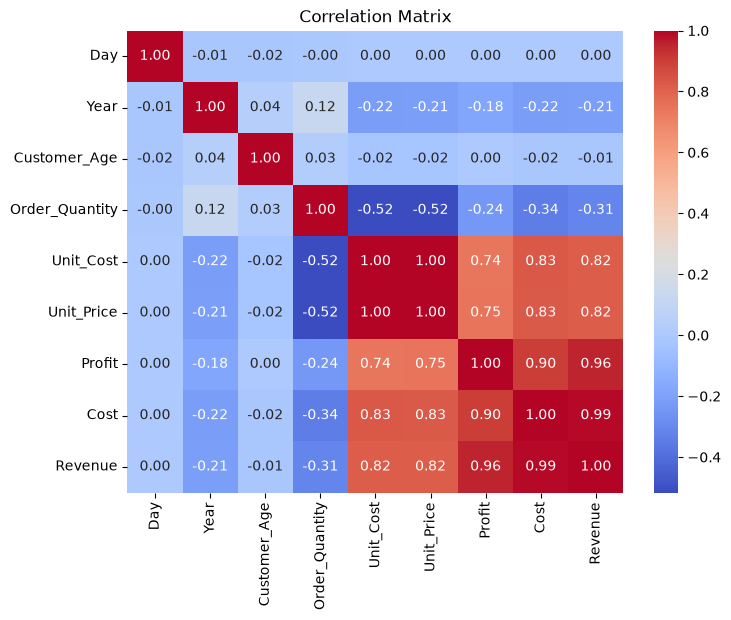

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()